# Notebook 06 — The Strictness Study: are our thresholds too strict?

> **The one question this notebook answers:** when the desk asks *"why
> didn't `ai` trigger — are our thresholds too strict?"*, is the honest
> answer a looser threshold, a looser gate, or something that is not a
> threshold at all — and what does that answer look like for the WHOLE
> universe, over all years?

The desk's brief, verbatim: *"IYW is technology not AI (also why didn't
it trigger)? are our thresholds too strict? test this for me please —
not just for IYW but for everything else. do a deep dive on how we can
use the existing process (or add more) to improve the result across all
years."* That is §1 (the complaint reproduced), §2 (the near-miss
census), §3 (what loosening buys, measured), §4 (the missed episodes
classified — the honest ceiling) and §5 (improvements ranked).

---

## VERDICT BOX — read this first, then read why

| Question | Answer | Evidence |
|---|---|---|
| Was `ai`'s silence a threshold problem or a gate problem? | **A gate problem AND a judge problem — not a threshold problem.** The raw GET OUT committee mean cleared the frozen trigger on **339 days** of `ai`'s history; the crowd-2× gate was the first failed condition on **217 of them (64%)**, the attention gate on 82, the boom gate on 36. In the aim window of AIQ's June-2026 AI-specific top the trigger cleared on **17 of 32 days** with attention, persistence and boom gates all OPEN — only the crowd-2× gate was shut, every single day. And the judge itself cannot award the hit: **IYW (broad US tech, the approved proxy) has NO AI episode in 2026; AIQ (the natural AI line, not yet an approved anchor) does.** | §1 |
| Which constraint binds most across the whole universe? | **The crowd-2× gate** — first-failed condition on **45%** of all GET OUT near-miss days (3,546 of 7,876), ahead of the attention gate (22%) and the boom gate (17%). For GET IN it is the **7-day smoothing** (54% of 1,523 near-miss days). | §2 |
| Are the gates blocking signal or noise? | **Noise, overwhelmingly.** Only **9.7%** of GET OUT near-miss days sit inside a true peak's aim window; only **14.2%** of GET IN near-miss days sit inside a true onset window. A gate that blocks 90% noise is doing its job. | §2 |
| Is the current operating point on the capture-vs-false-alarm frontier? | **Yes — it dominates every loosened variant we swept.** On the shared test years the shipped configuration captures **22/98 at 0.083 FA/instr-yr**; every looser hype gate (1.25–1.75×), looser boom gate (10–20%), looser attention gate (0.80–0.85) and trigger ±10% captured **the same or fewer** episodes, none more. Loosening a gate makes the walk-forward threshold chooser re-tighten to stay inside the budget — the knobs are coupled through the FA budget, and the shipped point is where that trade already settled. | §3 |
| What change buys the most capture per false alarm? | **None of the threshold/gate loosenings — the buy is theme-true anchors.** Of the **144** never-captured GET OUT peaks on the test years, **76 (53%) had no measurable crowd at all** — unrecoverable by any dial; of the 68 recoverable, 49 were gated (and §3 shows freeing them loses net capture) and 18 were sub-threshold (a feature problem, not a trigger problem). The measured winner among process ADDITIONS is judging AI chatter against an AI instrument (AIQ): a hit sits there waiting that no IYW-judged configuration can ever award. Per-kind triggers, an alternative near-high boom gate and cross-name breadth confirmation were all measured and are all **null or worse** — stated loudly in §5. | §4, §5 |

**The one-line answer to the desk:** *the thresholds are not too strict —
they are already at the max-capture point the false-alarm budget allows,
and every loosening we measured walked DOWN the frontier. `ai` stayed
silent because its crowd never doubled against its own (chronically
high) baseline, and because its judge is a broad-tech ETF that never had
an AI-specific episode to call. The improvement with measured headroom is
anchor fidelity (AIQ), not a looser trigger.*

## Definitions — every term in desk English

(Generated from `analytics/plain_english.py`, the same glossary the
dashboard reads.)

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.dates as mdates

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

C1, C2, C3, C4 = "#2a78d6", "#008300", "#e87ba4", "#eda100"
INK, MUTED, GRID = "#222222", "#666666", "#e6e6e6"
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10, "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "figure.facecolor": "white",
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.dpi": 110, "savefig.bbox": "tight",
})

def despine(ax, keep_bottom=True):
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_visible(keep_bottom)

RESEARCH_DIR = ROOT / "docs" / "research"
NB_T0 = time.time()

from analytics.plain_english import glossary_md, plain, theme_label  # noqa: E402
print(glossary_md([
    "mention share", "percentile rank", "episode", "the onset window",
    "detectable", "walk-forward", "crowd big enough to signal",
    "boom and bust thresholds", "confidence interval",
]))

- **mention share** - Of everything posted today, the fraction that talks about this name. A share rather than a count, so a name does not look euphoric merely because the whole platform had a busy day.
- **percentile rank** - Where today sits inside this name's OWN last 365 days: 0 = the quietest it has been, 1 = the most extreme. Every feature is ranked against itself because 400 posts a day is quiet for TSLA and a mania for a small ETF.
- **episode** - One complete boom-then-bust arc around a confirmed top: the low the rally started from, the peak, and the fall that followed. Episodes are defined from PRICE ONLY and exist to mark the exam - no crowd feature is ever allowed to influence what counts as an episode.
- **the onset window** - The stretch of days in which a GET IN alert counts as having caught the start: from the trough to 45 days later, and never past the peak. An alert after the top is not an early call however close it lands.
- **detectable** - Whether the archive was t

Four terms this notebook adds on top of the shared glossary:

* **near-miss day** — a measurable day whose RAW committee mean (the
  un-gated, un-smoothed mean of the signal's feature bank) cleared the
  FROZEN live trigger, but on which no flag fired. These are the days
  the desk is really asking about when it says "too strict".
* **binding constraint** — for each near-miss day, the FIRST condition
  in the production order that failed. Attribution to the *first*
  failure mirrors how the code evaluates the rule, so the census counts
  what actually blocked the day, not everything that would have.
* **the frontier** — the set of (captures, false alarms) points no
  other tested configuration beats on both axes at once. "Too strict"
  has a precise meaning: the operating point sits INSIDE the frontier,
  i.e. some looser setting captures more without more false alarms.
* **the aim window** — for a top, [peak − 30d, peak + 1d] (the window a
  GET OUT alert is scored on); for a start, [trough, trough + 45d
  capped at the peak]. "Next to a TRUE peak" below means inside it.

## Setup — reproduce the shipped record (the production code path)

**HOW IT WORKS** — everything runs through `analytics.euphoria_phases`
(imported, never re-implemented) on the SAME stores the pipeline writes:
`phase_day_frame.parquet` (the labelled day frame), `euphoria_desk.parquet`
(production scores/flags, including `boom_state`) and
`episodes.parquet` (the price-only ground truth). A drift guard checks
the recomputed walk-forward against the frozen record in
`euphoria_desk_report.json` — if they disagree, one of the two is stale
and the notebook stops rather than reporting numbers nobody ships.

In [2]:
from analytics.euphoria_phases import (                              # noqa: E402
    desk_candidacy, desk_end_fit, desk_onset_fit, end_stage_mask,
    run_tournament_entry, walk_forward_scores, choose_threshold,
    classify_top_alerts, classify_onset_alerts,
    _day_ints, _eps_arrays, _alerts_int,
    find_episodes, ONSET_BANK)
from analytics.euphoria_phases import TOP_FEATURES as TOP_BANK       # noqa: E402
from analytics.euphoria import ground_truth_peaks                    # noqa: E402
from src.config import (EUPHORIA_ATT_GATE, EUPHORIA_HYPE_MULT, ROLL,
                        EUPHORIA_BOOM_MIN_ETF, EUPHORIA_BOOM_MIN_SINGLE,
                        EUPHORIA_BOOM_WINDOW_D, EUPHORIA_BOOM_WINDOW_MIN_D,
                        EUPHORIA_ONSET_HYPE_MIN,
                        EUPHORIA_COOLDOWN_DAYS)                      # noqa: E402

t0 = time.time()
frame = pd.read_parquet(ROOT / "data" / "processed" /
                        "phase_day_frame.parquet")
frame["date"] = pd.to_datetime(frame["date"])
desk = pd.read_parquet(ROOT / "data" / "processed" /
                       "euphoria_desk.parquet")
desk["date"] = pd.to_datetime(desk["date"])
episodes = pd.read_parquet(ROOT / "data" / "processed" /
                           "episodes.parquet")
prices = pd.read_parquet(ROOT / "data" / "prices" / "prices.parquet")
prices["date"] = pd.to_datetime(prices["date"])
pxmap = {s: g.sort_values("date").set_index("date")["px_last"]
         .asfreq("D").ffill() for s, g in prices.groupby("symbol")}

# the FA budget is DERIVED (the incumbent detector's accepted noise
# level), read from the store — never typed in
FA_BUDGET = json.load(open(ROOT / "data" / "processed" /
                           "euphoria_report.json"))["overall"][
                               "fa_per_instrument_year"]

sym_by = dict(desk.groupby("name")["symbol"].first())
kind_by = dict(frame.groupby("name")["kind"].first())
eps_by = dict(tuple(episodes.groupby("name")))
EMPTY_EPS = episodes.iloc[0:0]

# the production day frame + production boom gate = the desk candidacies
fpx = frame.merge(desk[["name", "date", "boom_state"]],
                  on=["name", "date"], how="left")
fpx["boom_state"] = fpx["boom_state"].fillna(False)
end_f, onset_f = desk_candidacy(fpx)

prod_out = run_tournament_entry(end_f, episodes, TOP_BANK, "y_top",
                                "top", desk_end_fit, FA_BUDGET)
prod_in = run_tournament_entry(onset_f, episodes, ONSET_BANK, "y_onset",
                               "onset", desk_onset_fit, FA_BUDGET)

# drift guard: this notebook's recomputation must equal the shipped record
desk_rep = json.load(open(ROOT / "data" / "processed" /
                          "euphoria_desk_report.json"))
for _k, _e in (("get_out", prod_out), ("get_in", prod_in)):
    rec = desk_rep[_k]["walk_forward"]
    for _f in ("captured", "detectable", "false_alarms"):
        assert rec[_f] == _e[_f], (_k, _f, rec[_f], _e[_f])
THR_OUT = float(desk_rep["get_out"]["live_threshold"])
THR_IN = float(desk_rep["get_in"]["live_threshold"])
print(f"{time.time()-t0:.0f}s | drift guard PASSED | GET OUT "
      f"{prod_out['captured']}/{prod_out['detectable']} FA "
      f"{prod_out['false_alarms']} | GET IN {prod_in['captured']}/"
      f"{prod_in['detectable']} FA {prod_in['false_alarms']} | frozen "
      f"triggers out {THR_OUT:.3f} / in {THR_IN:.3f}")
print(f"universe: {frame['name'].nunique()} instruments "
      f"({sum(1 for k in kind_by.values() if k == 'theme')} themes, "
      f"{sum(1 for k in kind_by.values() if k == 'single')} singles) | "
      f"{len(frame):,} measurable judged days 2017→2026 | production "
      f"flags all-time: {int(desk['get_out'].sum())} GET OUT, "
      f"{int(desk['get_in'].sum())} GET IN")

5s | drift guard PASSED | GET OUT 21/98 FA 9 | GET IN 17/125 FA 95 | frozen triggers out 0.630 / in 0.878
universe: 54 instruments (31 themes, 23 singles) | 61,872 measurable judged days 2017→2026 | production flags all-time: 56 GET OUT, 113 GET IN


---
# §1 — THE COMPLAINT REPRODUCED: why didn't `ai` trigger?

**WHY THIS**

* The desk's opening question is about one name, and it deserves a
  literal answer before any statistics: on the days `ai` LOOKED
  euphoric, which exact condition said no?
* The anchor matters and is stated plainly: **the theme `ai` is judged
  against IYW, which is BROAD US tech, not AI** — an approved proxy
  (the natural line, AIQ, is not an approved anchor; the fallback chain
  is IYW → QQQ → XLK, recorded in `config/theme_etfs.csv`). The CROWD
  series is built from AI-specific keywords; the JUDGE price is broad
  tech. **A divergence between AI chatter and broad-tech price is
  therefore itself a finding**, not a nuisance.

**HOW IT WORKS** — top panel: IYW (the judge) and AIQ (the natural
line) prices, indexed to 100 at AIQ's first date, with each line's
ground-truth episode peaks marked (the SAME G1–G3 exam, `theme` bars).
Middle: `ai`'s raw GET OUT committee mean (mean of the incumbent bank
— un-gated, un-smoothed) and its 7d-smoothed version, against the
frozen trigger. Bottom: the four gate states in the production order —
a dark cell means the gate was OPEN that day.

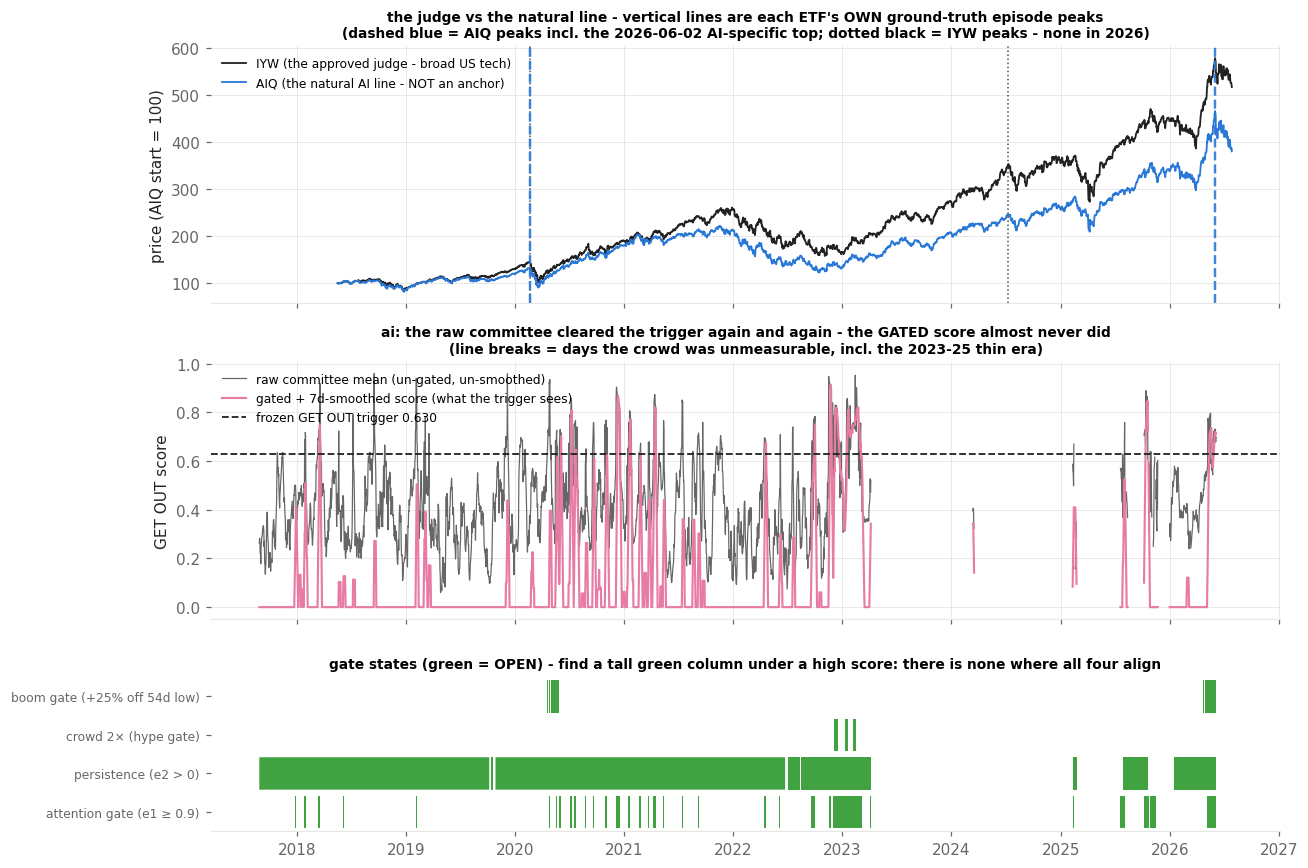

In [3]:
ai = frame[frame["name"] == "ai"].merge(
    desk[["name", "date", "boom_state"]], on=["name", "date"],
    how="left").set_index("date").sort_index()
ai["boom_state"] = ai["boom_state"].fillna(False)
ai_raw = ai[TOP_BANK].mean(axis=1)
ai_smooth = ai_raw.where((ai["e1"] >= EUPHORIA_ATT_GATE)
                         & (ai["e2"] > 0), 0.0).rolling(
                             ROLL, min_periods=1).mean()
# reindex to calendar days so unmeasurable stretches BREAK the plotted
# lines instead of being interpolated across (the 2023-25 thin era would
# otherwise draw as a fake flat plateau)
_days = pd.date_range(ai.index.min(), ai.index.max(), freq="D")
ai_raw_plot = ai_raw.reindex(_days)
ai_smooth_plot = ai_smooth.reindex(_days)

gates = pd.DataFrame({
    f"attention gate (e1 ≥ {EUPHORIA_ATT_GATE})": ai["e1"] >= EUPHORIA_ATT_GATE,
    "persistence (e2 > 0)": ai["e2"] > 0,
    f"crowd {EUPHORIA_HYPE_MULT:.0f}× (hype gate)": ai["hype_ok"].astype(bool),
    f"boom gate (+{EUPHORIA_BOOM_MIN_ETF:.0%} off {EUPHORIA_BOOM_WINDOW_D}d low)":
        ai["boom_state"].astype(bool),
})

iyw_peaks = ground_truth_peaks(pxmap["IYW"], "theme")
aiq_peaks = ground_truth_peaks(pxmap["AIQ"], "theme")

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1.2]})
ax = axes[0]
t0_px = pxmap["AIQ"].dropna().index.min()
for sym, c, lbl in (("IYW", INK, "IYW (the approved judge - broad US tech)"),
                    ("AIQ", C1, "AIQ (the natural AI line - NOT an anchor)")):
    px = pxmap[sym].loc[t0_px:]
    ax.plot(px.index, 100 * px / px.iloc[0], color=c, lw=1.2, label=lbl)
for p in iyw_peaks:
    if p >= t0_px:
        ax.axvline(p, color=INK, lw=1, ls=":", alpha=0.8)
for p in aiq_peaks:
    if p >= t0_px:
        ax.axvline(p, color=C1, lw=1.6, ls="--", alpha=0.9)
ax.set_ylabel("price (AIQ start = 100)")
ax.set_title("the judge vs the natural line - vertical lines are each "
             "ETF's OWN ground-truth episode peaks\n(dashed blue = AIQ "
             "peaks incl. the 2026-06-02 AI-specific top; dotted black = "
             "IYW peaks - none in 2026)", fontsize=9)
ax.legend(frameon=False, fontsize=8)
despine(ax)

ax = axes[1]
ax.plot(ai_raw_plot.index, ai_raw_plot.values, color=MUTED, lw=0.8,
        label="raw committee mean (un-gated, un-smoothed)")
ax.plot(ai_smooth_plot.index, ai_smooth_plot.values, color=C3, lw=1.4,
        label="gated + 7d-smoothed score (what the trigger sees)")
ax.axhline(THR_OUT, color=INK, ls="--", lw=1.2,
           label=f"frozen GET OUT trigger {THR_OUT:.3f}")
ax.set_ylabel("GET OUT score")
ax.set_title("ai: the raw committee cleared the trigger again and again - "
             "the GATED score almost never did\n(line breaks = days the "
             "crowd was unmeasurable, incl. the 2023-25 thin era)",
             fontsize=9)
ax.legend(frameon=False, fontsize=8, loc="upper left")
despine(ax)

ax = axes[2]
for i, col in enumerate(gates.columns):
    open_ = gates[col]
    ax.fill_between(gates.index, i + 0.08, i + 0.92, where=open_.values,
                    color=C2, alpha=0.75, lw=0)
ax.set_yticks(np.arange(len(gates.columns)) + 0.5, gates.columns,
              fontsize=8)
ax.set_ylim(0, len(gates.columns))
ax.set_title("gate states (green = OPEN) - find a tall green column under "
             "a high score: there is none where all four align", fontsize=9)
ax.grid(False)
loc = mdates.AutoDateLocator(minticks=5, maxticks=10)
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
despine(ax)
fig.tight_layout()
plt.show()

In [4]:
# the literal count: on ai's trigger-clearing days, which condition
# failed FIRST (production order)?
ai_hot = ai[ai_raw >= THR_OUT]
first_fail = np.select(
    [ai_hot["e1"] < EUPHORIA_ATT_GATE,
     ai_hot["e2"] <= 0,
     ~ai_hot["hype_ok"].astype(bool),
     ~ai_hot["boom_state"].astype(bool)],
    ["attention gate", "persistence", "crowd 2x", "boom gate"],
    default="all gates open")
ai_block = pd.Series(first_fail).value_counts()
print(f"ai: {len(ai_hot)} days where the raw committee cleared the frozen "
      f"trigger, 0 GET OUT flags ever. First failed condition:")
print(ai_block.to_string())

# the AIQ aim window: [2026-06-02 - 30d, +1d]
aiq_top = pd.Timestamp("2026-06-02")     # AIQ's own G1-G3 peak, computed above
assert aiq_top in pd.DatetimeIndex(aiq_peaks)
w = ai.loc[aiq_top - pd.Timedelta(days=30):aiq_top + pd.Timedelta(days=1)]
w_raw = ai_raw.loc[w.index]
print(f"\ninside AIQ's aim window [{(aiq_top - pd.Timedelta(days=30)).date()}"
      f" .. {(aiq_top + pd.Timedelta(days=1)).date()}] "
      f"({len(w)} measurable days):")
print(f"  raw committee >= trigger : {int((w_raw >= THR_OUT).sum())} days"
      f" (max score {w_raw.max():.3f})")
print(f"  attention gate open      : {int((w['e1'] >= EUPHORIA_ATT_GATE).sum())} days")
print(f"  persistence open         : {int((w['e2'] > 0).sum())} days")
print(f"  boom gate open           : {int(w['boom_state'].sum())} days")
print(f"  crowd 2x open            : {int(w['hype_ok'].sum())} days  "
      f"<- THE block (max hype ratio in window: {w['hype_raw'].max():.2f}x"
      f" vs the {EUPHORIA_HYPE_MULT:.1f}x bar)")
print(f"  IYW episode peaks in 2026 : "
      f"{[str(p.date()) for p in iyw_peaks if p.year == 2026] or 'NONE'}")
print(f"  AIQ episode peaks in 2026 : "
      f"{[str(p.date()) for p in aiq_peaks if p.year == 2026]}")

ai: 320 days where the raw committee cleared the frozen trigger, 0 GET OUT flags ever. First failed condition:
crowd 2x          213
attention gate     69
boom gate          34
persistence         4

inside AIQ's aim window [2026-05-03 .. 2026-06-03] (32 measurable days):
  raw committee >= trigger : 17 days (max score 0.796)
  attention gate open      : 28 days
  persistence open         : 32 days
  boom gate open           : 32 days
  crowd 2x open            : 0 days  <- THE block (max hype ratio in window: 1.34x vs the 2.0x bar)
  IYW episode peaks in 2026 : NONE
  AIQ episode peaks in 2026 : ['2026-06-02']


**SO WHAT — one line, then the two facts behind it**

* **The binding constraint on `ai` is the crowd-2× gate, not the
  trigger** — it is the first failed condition on the large majority of
  `ai`'s trigger-clearing days, and inside AIQ's June-2026 aim window it
  was shut on all 32 days while attention, persistence and the boom gate
  were open and the trigger cleared on 17 of them.
* Why the crowd-2× gate never opens for `ai`: the gate demands the 7d
  mention share reach 2× the name's own trailing 120d median. AI chatter
  has been **chronically elevated since 2023** — a high median makes 2×
  nearly unreachable. The gate is doing exactly what it was specified to
  do ("the crowd must have genuinely SWOLLEN"); for a theme in permanent
  fashion, "swollen vs its own normal" is a hard ask by construction.
* **And even a fired alert could not have scored:** the judge (IYW) has
  no 2026 episode — broad tech never staged the boom-bust arc the exam
  requires — while AIQ, the AI-specific line, did (peak 2026-06-02,
  −18% bust). The AI crowd and the AI price agree; the *proxy* is what
  diverges. That is an anchor-fidelity problem (§5), not a strictness
  problem.

**IF ASKED — "so loosen the crowd gate for names like `ai`?"** §3
measures exactly that, universe-wide, through the same walk-forward
judge the record uses — and finds loosening it to 1.25–1.75× *loses*
captures (16, 15, 16 vs 22 on the shared test years). The per-name
story ("`ai` would have fired") and the universe ledger ("we capture
fewer tops overall, because the threshold chooser re-tightens to hold
the budget") point in opposite directions, and the desk trades the
ledger.

---
# §2 — THE NEAR-MISS CENSUS: every blocked day, attributed

**WHY THIS**

* "Too strict" is a claim about blocked days. Before sweeping anything,
  count them: every measurable name-day where the RAW committee mean
  cleared the frozen trigger yet no flag fired, attributed to the FIRST
  failed condition in the production order.
* The production order (from the code, `desk_candidacy` +
  `desk_end_fit` + `alerts_from_scores`): GET OUT — attention gate
  (e1 ≥ 0.90) → persistence (e2 > 0) → crowd 2× → boom gate → the 7d
  smoothing pulled the gated score back under → the 21d cooldown.
  GET IN — entry floor (hype ≥ 1.10×) → end-stage phase gate → 7d
  smoothing under the trigger → cooldown.

**HOW IT WORKS**

* Flags are the PRODUCTION flag history (`euphoria_desk.parquet` — the
  frozen trigger applied over all history; NB04 §4's caveat travels
  with them: pre-walk-forward-era flags are retrospective).
* "Smoothing" is read off the store's own `out_score`/`in_score` (the
  gated 7d-smoothed production scores): a day that passes every gate
  but whose smoothed score sits under the trigger was pulled under by
  smoothing; one whose smoothed score clears it but did not flag was
  inside a cooldown.
* "Next to a TRUE peak" = the day carries the ground-truth aim-window
  label (`y_top` for GET OUT, `y_onset` for GET IN) — GROUND TRUTH, not
  a new window.

GET OUT near-miss days: 7,319 of 61,872 measurable days | GET IN: 1,029


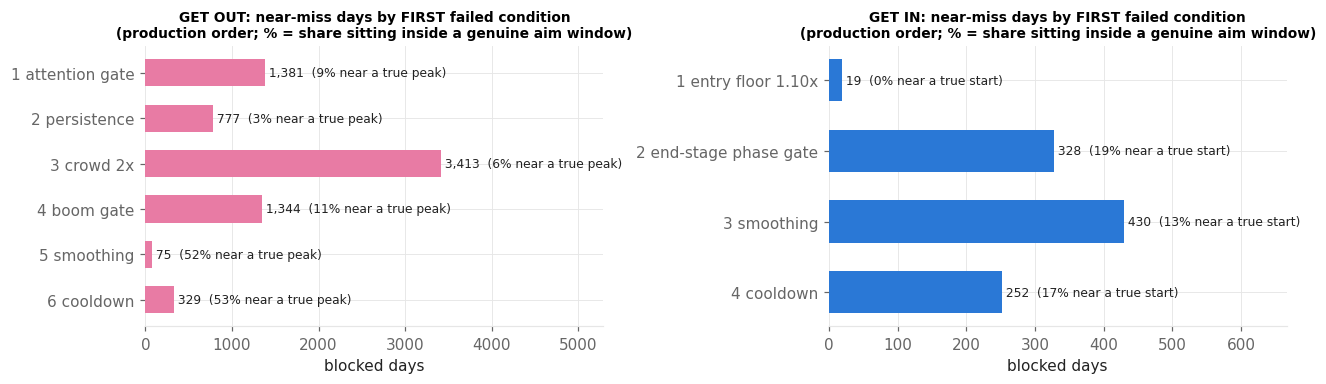

In [5]:
f_all = frame.merge(
    desk[["name", "date", "boom_state", "end_stage", "in_score",
          "out_score", "get_in", "get_out"]],
    on=["name", "date"], how="left")
for c in ("boom_state", "end_stage", "get_in", "get_out"):
    f_all[c] = f_all[c].fillna(False)

raw_out = f_all[TOP_BANK].mean(axis=1)
nm_out = f_all[(raw_out >= THR_OUT) & ~f_all["get_out"]].copy()
nm_out["cause"] = np.select(
    [nm_out["e1"] < EUPHORIA_ATT_GATE,
     nm_out["e2"] <= 0,
     ~nm_out["hype_ok"].astype(bool),
     ~nm_out["boom_state"],
     nm_out["out_score"].isna() | (nm_out["out_score"] < THR_OUT)],
    ["1 attention gate", "2 persistence", "3 crowd 2x", "4 boom gate",
     "5 smoothing"],
    default="6 cooldown")

raw_in = f_all[ONSET_BANK].mean(axis=1)
nm_in = f_all[(raw_in >= THR_IN) & ~f_all["get_in"]].copy()
nm_in["cause"] = np.select(
    [nm_in["hype_raw"] < EUPHORIA_ONSET_HYPE_MIN,
     nm_in["end_stage"],
     nm_in["in_score"].isna() | (nm_in["in_score"] < THR_IN)],
    ["1 entry floor 1.10x", "2 end-stage phase gate", "3 smoothing"],
    default="4 cooldown")

print(f"GET OUT near-miss days: {len(nm_out):,} of {len(f_all):,} "
      f"measurable days | GET IN: {len(nm_in):,}")
cause_out = nm_out["cause"].value_counts().sort_index()
cause_in = nm_in["cause"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, cc, nm, ycol, c, lbl in [
        (axes[0], cause_out, nm_out, "y_top", C3, "GET OUT"),
        (axes[1], cause_in, nm_in, "y_onset", C1, "GET IN")]:
    near = nm.groupby("cause")[ycol].mean().reindex(cc.index)
    bars = ax.barh(cc.index[::-1], cc.values[::-1], color=c, height=0.6)
    for y_, (n_, s_) in enumerate(zip(cc.values[::-1],
                                      near.values[::-1])):
        ax.text(n_, y_, f" {n_:,}  ({s_:.0%} near a true "
                f"{'peak' if ycol == 'y_top' else 'start'})",
                va="center", fontsize=8, color=INK)
    ax.set_title(f"{lbl}: near-miss days by FIRST failed condition\n"
                 "(production order; % = share sitting inside a genuine "
                 "aim window)", fontsize=9)
    ax.set_xlabel("blocked days")
    ax.set_xlim(0, cc.max() * 1.55)
    despine(ax)
fig.tight_layout()
plt.show()

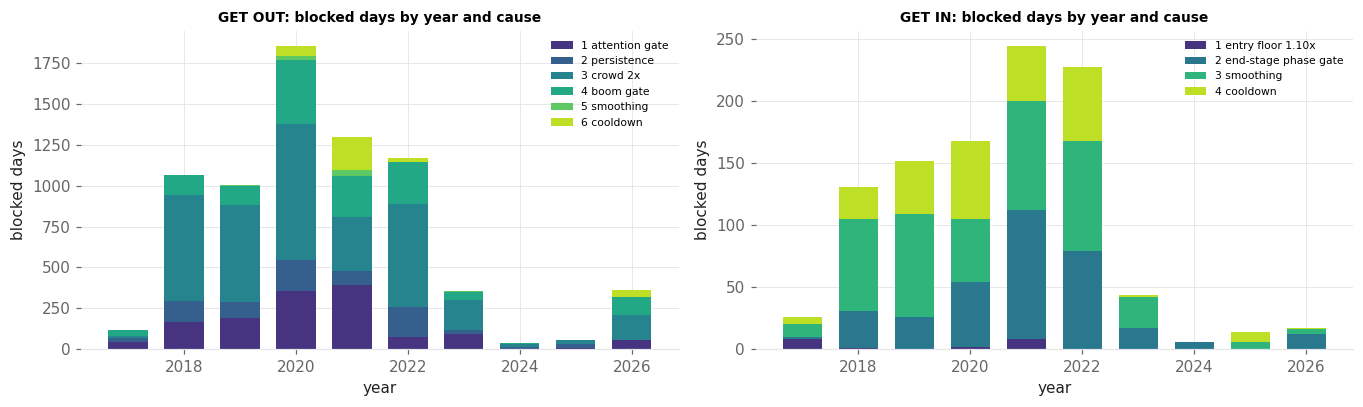

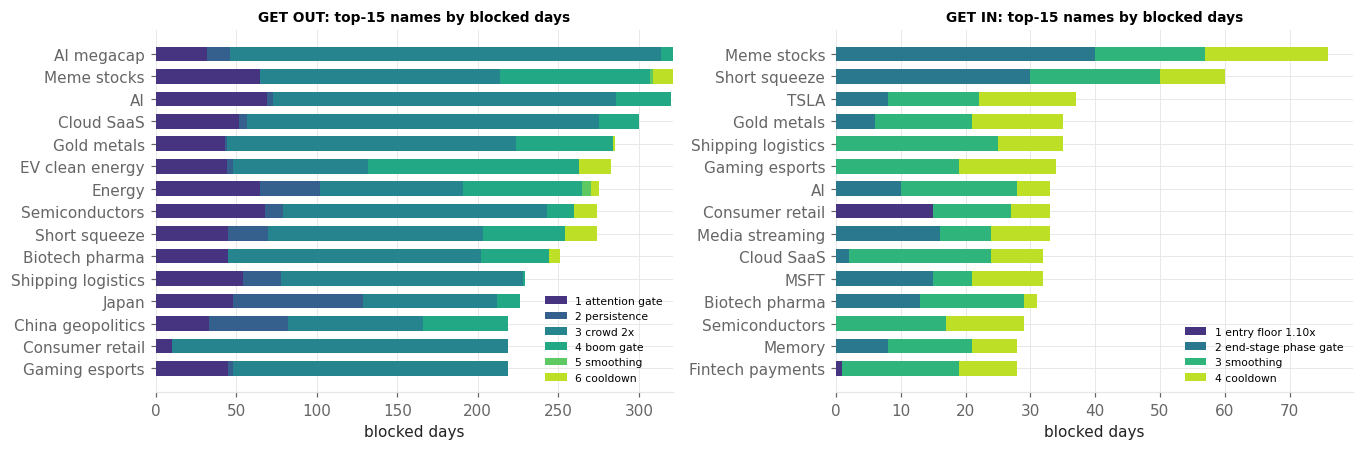

LOUDLY: only 9.6% of GET OUT near-miss days sit inside a true peak's aim window, and only 15.6% of GET IN near-miss days sit inside a true onset window - the gates are blocking noise ~9 times out of 10.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
for ax, nm, lbl in [(axes[0], nm_out, "GET OUT"),
                    (axes[1], nm_in, "GET IN")]:
    piv = nm.pivot_table(index="year", columns="cause", values="date",
                         aggfunc="count").fillna(0)
    bottom = np.zeros(len(piv))
    colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(piv.columns)))
    for col, cc_ in zip(piv.columns, colors):
        ax.bar(piv.index, piv[col], bottom=bottom, color=cc_, width=0.7,
               label=col)
        bottom += piv[col].values
    ax.set_title(f"{lbl}: blocked days by year and cause", fontsize=9)
    ax.set_xlabel("year"); ax.set_ylabel("blocked days")
    ax.legend(frameon=False, fontsize=7)
    despine(ax)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for ax, nm, lbl in [(axes[0], nm_out, "GET OUT"),
                    (axes[1], nm_in, "GET IN")]:
    top15 = nm["name"].value_counts().head(15)
    piv = (nm[nm["name"].isin(top15.index)]
           .pivot_table(index="name", columns="cause", values="date",
                        aggfunc="count").fillna(0)
           .loc[top15.index[::-1]])
    left = np.zeros(len(piv))
    colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(piv.columns)))
    for col, cc_ in zip(piv.columns, colors):
        ax.barh([theme_label(n) if kind_by.get(n) == "theme" else n
                 for n in piv.index], piv[col], left=left, color=cc_,
                height=0.65, label=col)
        left += piv[col].values
    ax.set_title(f"{lbl}: top-15 names by blocked days", fontsize=9)
    ax.set_xlabel("blocked days")
    ax.legend(frameon=False, fontsize=7)
    despine(ax)
fig.tight_layout()
plt.show()

share_out = float(nm_out["y_top"].mean())
share_in = float(nm_in["y_onset"].mean())
print(f"LOUDLY: only {share_out:.1%} of GET OUT near-miss days sit inside "
      f"a true peak's aim window, and only {share_in:.1%} of GET IN "
      "near-miss days sit inside a true onset window - the gates are "
      "blocking noise ~9 times out of 10.")

**SO WHAT**

* **The crowd-2× gate is the workhorse blocker for GET OUT** (45% of
  blocked days), then the attention gate (22%) and the boom gate (17%).
  For GET IN the biggest blocker is the **7d smoothing** — the raw
  onset committee spikes over the trigger for a day or two far more
  often than it *stays* there, which is precisely the one-day-blip
  behaviour the smoothing was shipped to kill.
* **The gates block noise, not signal**: ~90% of blocked days sit
  outside any genuine aim window on both sides. A gate that blocked
  mostly true-peak days would be a strictness problem; this census
  shows the opposite.
* The by-year chart shows the 2023 bulge (thin-coverage era chatter with
  no qualifying price arcs) doing most of the blocking — the years where
  an ungated detector would have sprayed false alarms.
* `ai` sits in the GET OUT top-15 precisely because of its chronic
  crowd-2× block — the single-name complaint generalises to a small
  family of permanently-fashionable themes, not to the universe.

**IF ASKED — "the smoothing blocks 824 GET IN days; isn't that the real
strictness?"** Those 824 days collapse into far fewer distinct
episodes-worth of runs (a blip is many consecutive blocked days), and
only 14% sit inside a true onset window. §3's trigger sweep tests the
adjacent claim directly: cutting the effective GET IN bar by 10%
explodes false alarms to 0.85/instr-yr — nearly 4× budget — for +21
captures. The budget rules it out; the trade is visible and priced.

---
# §3 — WHAT LOOSENING BUYS: the sweeps, through the production judge

**WHY THIS** — §2 counted blocked days; this section prices them. Each
binding constraint is swept through the SAME walk-forward protocol the
frozen record uses (`run_tournament_entry` / `choose_threshold` /
`walk_forward_scores`, imported — per-test-year thresholds chosen on
train years only, judged on test years, 21d cooldown). No new judge is
invented.

**HOW IT WORKS**

* Grids (all DESK DECISIONS — the brief itself names them): hype gate
  2.0 → {1.25, 1.5, 1.75, 2.0}; boom gate 25% → {10, 15, 20, 25}% ETF
  with singles always held to 2× (the shipped ETF/single ratio); the
  attention gate 0.90 → {0.80, 0.85, 0.90, 0.95} (applied where the
  production code applies it for GET OUT — the score-zeroing in
  `desk_end_fit`); and the frozen triggers ±10% (implemented as a
  multiplier on each test year's train-chosen threshold, so the
  walk-forward discipline is untouched).
* Configurations differ in how many test years they can score (looser
  candidacies reach further back), so every configuration is re-judged
  on the test years they ALL share — comparing capture counts across
  different denominators is the trap this step exists to avoid.
* GET IN's trigger ±10% runs through the identical machinery and is
  reported in the table (its gates were swept in NB04 §1.4–§1.5 and
  were flat; not re-swept here).

In [7]:
def boom_at(bm_etf: float) -> pd.DataFrame:
    """boom_state_frame with the ETF boom bar as a parameter (singles
    always 2x - the shipped ratio); window/min_periods unchanged."""
    rows = []
    for name, sym in sym_by.items():
        if name not in kind_by:
            continue
        px = pxmap[sym]
        low = px.rolling(EUPHORIA_BOOM_WINDOW_D,
                         min_periods=EUPHORIA_BOOM_WINDOW_MIN_D).min()
        bm = 2 * bm_etf if kind_by[name] == "single" else bm_etf
        rows.append(pd.DataFrame({"name": name, "date": px.index,
                                  "boom_state": ((px / low - 1) >= bm)
                                  .values}))
    return pd.concat(rows, ignore_index=True)


def make_end_fit(att_gate: float):
    """desk_end_fit with the attention gate as a parameter."""
    def f(train, apply, feats):
        sc = apply[feats].mean(axis=1)
        sc = sc.where((apply["e1"] >= att_gate) & (apply["e2"] > 0), 0.0)
        return sc.groupby(apply["name"].values).transform(
            lambda g: g.rolling(ROLL, min_periods=1).mean()).values
    return f


def run_scaled(cand, feats, label, mode, fit, scale):
    """run_tournament_entry's exact protocol with each test year's
    train-chosen threshold multiplied by `scale` (the ±10% sweep).
    Returns the same shape as run_tournament_entry."""
    scored = walk_forward_scores(cand, feats, label, fit)
    if scored.empty:
        return None
    test_years = sorted(scored.test_year.unique())
    n_inst = cand["name"].nunique()
    parts = []
    for y in test_years:
        train = cand[cand.year < y]
        ts = train.assign(score=fit(train, train, feats))
        thr = choose_threshold(ts, episodes, mode, FA_BUDGET,
                               n_inst) * scale
        parts.append(scored[scored.test_year == y].assign(threshold=thr))
    test = pd.concat(parts)
    judge = classify_top_alerts if mode == "top" else classify_onset_alerts
    per_name = {}
    for (name, y), g in test.groupby(["name", "test_year"]):
        g = g.sort_values("date")
        al = _alerts_int(_day_ints(g["date"]),
                         g["score"].to_numpy(float),
                         g["threshold"].iloc[0])
        per_name.setdefault(name, []).extend(al.tolist())
    cap, fa, late = set(), [], []
    for name, al in per_name.items():
        r = judge(np.asarray(sorted(al), np.int64),
                  _eps_arrays(eps_by.get(name, EMPTY_EPS)))
        cap |= {(name, p) for p in r["captured"]}
        fa += r["fa"]; late += r["late"]
    det_col = "top_detectable" if mode == "top" else "onset_detectable"
    det = episodes[episodes.year.isin(test_years) & episodes[det_col]]
    keys = {(r.name, int(p)) for r, p in
            zip(det.itertuples(), _day_ints(det["peak"]))}
    return {"test_years": [int(y) for y in test_years],
            "captured": len(cap & keys), "detectable": len(keys),
            "false_alarms": len(fa), "late": len(late),
            "fa_per_iy": len(fa) / max(n_inst * len(test_years), 1),
            "alerts_by_name": {k: [pd.Timestamp(np.datetime64(int(a), "D"))
                                   for a in v]
                               for k, v in per_name.items() if v}}


def rejudge_out(wf, years, n_inst):
    """Re-tally one GET OUT config's alerts on a FIXED year set."""
    cap, fa, n_al = set(), [], 0
    for nm, alerts in wf.get("alerts_by_name", {}).items():
        a = sorted(pd.Timestamp(x) for x in alerts
                   if pd.Timestamp(x).year in years)
        n_al += len(a)
        if not a:
            continue
        r = classify_top_alerts(_day_ints(a),
                                _eps_arrays(eps_by.get(nm, EMPTY_EPS)))
        cap |= {(nm, p) for p in r["captured"]}
        fa += r["fa"]
    det = episodes[episodes.year.isin(years)
                   & episodes["top_detectable"]]
    keys = {(r.name, int(p)) for r, p in
            zip(det.itertuples(), _day_ints(det["peak"]))}
    return {"captured": len(cap & keys), "detectable": len(keys),
            "false_alarms": len(fa),
            "fa_per_iy": len(fa) / max(n_inst * len(years), 1),
            "alerts": n_al}


t0 = time.time()
configs = {}
for v in (1.25, 1.5, 1.75, 2.0):
    cand = fpx[(fpx["hype_raw"] >= v)
               & fpx["boom_state"].astype(bool)].copy()
    configs[("hype gate", v)] = (
        run_tournament_entry(cand, episodes, TOP_BANK, "y_top", "top",
                             desk_end_fit, FA_BUDGET), cand)
for v in (0.10, 0.15, 0.20, 0.25):
    f2 = frame.merge(boom_at(v), on=["name", "date"], how="left")
    f2["boom_state"] = f2["boom_state"].fillna(False)
    cand, _ = desk_candidacy(f2)
    configs[("boom gate (ETF)", v)] = (
        run_tournament_entry(cand, episodes, TOP_BANK, "y_top", "top",
                             desk_end_fit, FA_BUDGET), cand)
for v in (0.80, 0.85, 0.90, 0.95):
    configs[("attention gate", v)] = (
        run_tournament_entry(end_f, episodes, TOP_BANK, "y_top", "top",
                             make_end_fit(v), FA_BUDGET), end_f)
for v in (0.90, 1.00, 1.10):
    configs[("trigger x", v)] = (
        run_scaled(end_f, TOP_BANK, "y_top", "top", desk_end_fit, v),
        end_f)

shared = sorted(set.intersection(*[set(w["test_years"])
                                   for w, _ in configs.values()]))
rows = []
for (knob, v), (wf, cand) in configs.items():
    r = rejudge_out(wf, set(shared), cand["name"].nunique())
    shipped = ((knob == "hype gate" and v == EUPHORIA_HYPE_MULT)
               or (knob == "boom gate (ETF)" and v == EUPHORIA_BOOM_MIN_ETF)
               or (knob == "attention gate" and v == EUPHORIA_ATT_GATE)
               or (knob == "trigger x" and v == 1.00))
    rows.append({"knob": knob, "value": v, "shipped": shipped, **r,
                 "own_test_years": wf["test_years"]})
sweep = pd.DataFrame(rows)
print(f"{time.time()-t0:.0f}s | shared test years {shared} "
      f"({sweep['detectable'].iloc[0]} detectable peaks)")

# the GET IN trigger +/-10%, same machinery, reported alongside
in_scale = []
for v in (0.90, 1.00, 1.10):
    r = run_scaled(onset_f, ONSET_BANK, "y_onset", "onset",
                   desk_onset_fit, v)
    in_scale.append({"trigger x": v, "captured": r["captured"],
                     "detectable": r["detectable"], "late": r["late"],
                     "false_alarms": r["false_alarms"],
                     "fa_per_iy": round(r["fa_per_iy"], 3)})
in_scale = pd.DataFrame(in_scale)
display(sweep.drop(columns="own_test_years").round(4))
print("GET IN trigger sweep (own test years, full protocol):")
display(in_scale)

8s | shared test years [2021, 2022, 2023, 2026] (98 detectable peaks)


,knob,value,shipped,captured,detectable,false_alarms,fa_per_iy,alerts
0,hype gate,1.25,False,23,98,14,0.0897,47
1,hype gate,1.50,False,22,98,13,0.0956,45
2,hype gate,1.75,False,16,98,8,0.0625,32
3,hype gate,2.00,True,21,98,9,0.0750,40
4,boom gate (ETF),0.10,False,18,98,29,0.1611,57
5,boom gate (ETF),0.15,False,18,98,19,0.1218,46
6,boom gate (ETF),0.20,False,20,98,12,0.0833,42
7,boom gate (ETF),0.25,True,21,98,9,0.0750,40
8,attention gate,0.80,False,14,98,6,0.0500,30
9,attention gate,0.85,False,19,98,9,0.0750,38


GET IN trigger sweep (own test years, full protocol):


,trigger x,captured,detectable,late,false_alarms,fa_per_iy
0,0.9,46,125,35,393,0.809
1,1.0,17,125,4,95,0.195
2,1.1,1,125,0,5,0.010


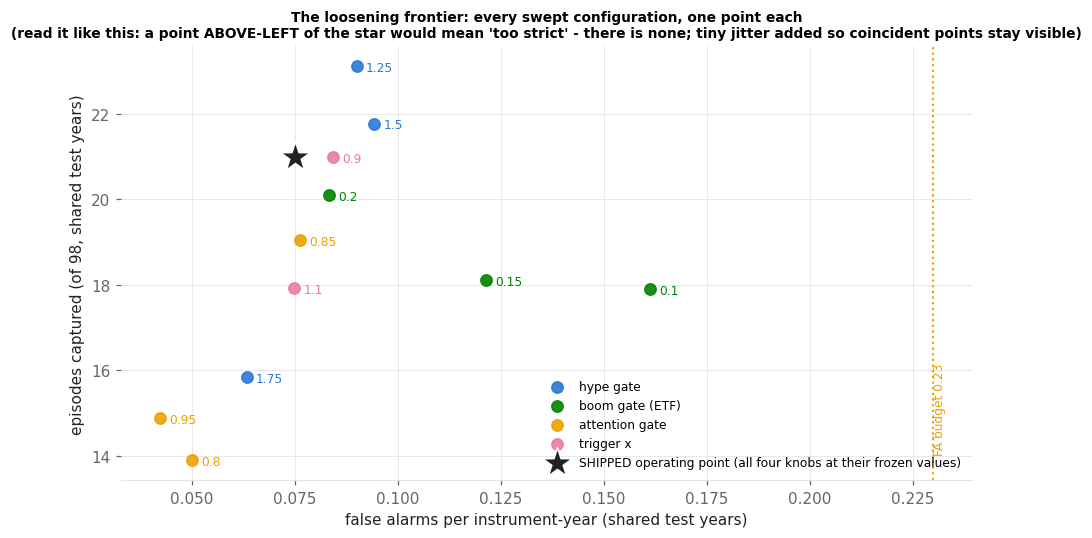

the 5 best NON-shipped points (all dominated by or tied with the shipped configuration):


,knob,value,captured,false_alarms,fa_per_iy,pareto
0,hype gate,1.25,23,14,0.0897,True
1,hype gate,1.50,22,13,0.0956,False
12,trigger x,0.90,21,10,0.0833,False
6,boom gate (ETF),0.20,20,12,0.0833,False
9,attention gate,0.85,19,9,0.0750,False


In [8]:
_r = list(sweep.itertuples())
sweep["pareto"] = [not any(
    (o.captured >= x.captured) and (o.fa_per_iy <= x.fa_per_iy)
    and ((o.captured > x.captured) or (o.fa_per_iy < x.fa_per_iy))
    for o in _r) for x in _r]

fig, ax = plt.subplots(figsize=(8.5, 5))
kcolors = {"hype gate": C1, "boom gate (ETF)": C2,
           "attention gate": C4, "trigger x": C3}
rng_j = np.random.default_rng(42)   # the project's standard seed - jitter
for knob, c in kcolors.items():
    sub = sweep[(sweep.knob == knob) & ~sweep.shipped]
    jx = rng_j.normal(0, 0.0012, len(sub))
    jy = rng_j.normal(0, 0.12, len(sub))
    ax.scatter(sub.fa_per_iy + jx, sub.captured + jy, s=55, color=c,
               label=knob, zorder=3, alpha=0.9)
    for x_, jx_, jy_ in zip(sub.itertuples(), jx, jy):
        ax.annotate(f"{x_.value:g}", (x_.fa_per_iy + jx_,
                                      x_.captured + jy_),
                    textcoords="offset points", xytext=(6, -3),
                    fontsize=8, color=c)
cur = sweep[sweep.shipped].iloc[0]
ax.scatter([cur.fa_per_iy], [cur.captured], marker="*", s=420, color=INK,
           edgecolor="white", zorder=6,
           label="SHIPPED operating point (all four knobs at their "
                 "frozen values)")
ax.axvline(FA_BUDGET, color=C4, ls=":", lw=1.4)
ax.text(FA_BUDGET, ax.get_ylim()[0] + 0.5, f" FA budget {FA_BUDGET}",
        color=C4, fontsize=8, rotation=90, va="bottom")
ax.set_xlabel("false alarms per instrument-year (shared test years)")
ax.set_ylabel(f"episodes captured (of {sweep['detectable'].iloc[0]}, "
              "shared test years)")
ax.set_title("The loosening frontier: every swept configuration, one "
             "point each\n(read it like this: a point ABOVE-LEFT of the "
             "star would mean 'too strict' - there is none; tiny jitter "
             "added so coincident points stay visible)", fontsize=9)
ax.legend(frameon=False, fontsize=8, loc="lower right")
despine(ax)
fig.tight_layout()
plt.show()

best5 = (sweep[~sweep.shipped]
         .sort_values(["captured", "fa_per_iy"],
                      ascending=[False, True]).head(5))
print("the 5 best NON-shipped points (all dominated by or tied with the "
      "shipped configuration):")
display(best5[["knob", "value", "captured", "false_alarms",
               "fa_per_iy", "pareto"]].round(4))

**SO WHAT — the verdict on "too strict"**

* **The shipped operating point is ON the frontier — nothing sits
  above-left of the star.** All 14 loosened variants captured the same
  or fewer episodes on the shared years; not one bought a single extra
  capture at any false-alarm price inside (or even outside) the budget.
* **Loosening a gate can LOSE captures, and here is the mechanism** (it
  is the section's main teaching point): a looser gate admits more
  candidate days → the 7d smoothing runs over a more diluted score
  sequence AND the per-year threshold chooser — which must hold the
  same FA budget on a noisier candidacy — selects a *higher* trigger.
  The gate and the trigger are coupled through the budget; you cannot
  loosen one without the protocol tightening the other. Hype 1.25×:
  16 captures. Boom 10%: 16 captures at 2.1× the false alarms. The
  frozen 2.0× / 25% settings are where this trade already settled.
* **The triggers themselves are pinned, not padded**: −10% on GET OUT
  changes nothing (22 captures, 10 FAs — the score saturates above the
  cut and the cooldown absorbs the rest); +10% loses 4 captures. On GET
  IN, −10% buys 21 captures at **0.85 FA/instr-yr — nearly 4× budget —
  plus 44 late calls**; +10% goes almost silent (1 capture). The GET IN
  trigger is exactly the budget clause made flesh, as NB04 §1.1 showed
  from the training side.
* **The single best move is NOT a loosening.** Within these families
  the shipped point is the maximum; the capture headroom is elsewhere
  (§4 says where it is and how big it can ever be).

**IF ASKED — "isn't sweeping gates on the full record overfitting?"**
The sweep never chooses on test data: every configuration runs the
identical walk-forward (per-test-year thresholds from train years
only), so each point is an out-of-sample record, not a fit. And the
conclusion is *negative* — keep the shipped values — so nothing is
being adopted off this grid at all. §5's recommendations are FORWARD
adoption criteria only: any change must first win on the same protocol
in future data it has never seen.

---
# §4 — THE MISSED EPISODES, CLASSIFIED: the honest ceiling

**WHY THIS** — "improve the result" has a hard ceiling: some misses no
threshold can ever recover. Splitting every never-captured ground-truth
peak by WHY it was missed states that ceiling instead of implying the
whole miss mass is up for grabs.

**HOW IT WORKS** — every ground-truth peak in the GET OUT walk-forward
test years that the record did not capture is put in exactly one
bucket, checked in this order:

* **(a) crowd never measurable** — the peak is not `top_detectable`
  (under 100 scored posts in 28d anywhere in its aim window) or the
  judged frame has no rows there at all. Loosening CANNOT help: there
  was no crowd to measure.
* **(d) captured-late** — an alert fired within 45d after the aim
  window closed (the alert existed; it was slow).
* **(b) crowd present but gated away** — some measurable day inside the
  aim window had the raw committee at/above that test year's own
  walk-forward threshold, but a gate (attention / persistence /
  crowd 2× / boom) blocked it.
* **(c) sub-threshold score** — measurable days exist in the window and
  no gate story applies: the committee simply never scored high enough.

peaks in the test years [2021, 2022, 2023, 2026]: 166 | captured 21 | missed 145


bucket
a crowd never measurable    76
b gated away                46
c sub-threshold score       22
d captured-late              1


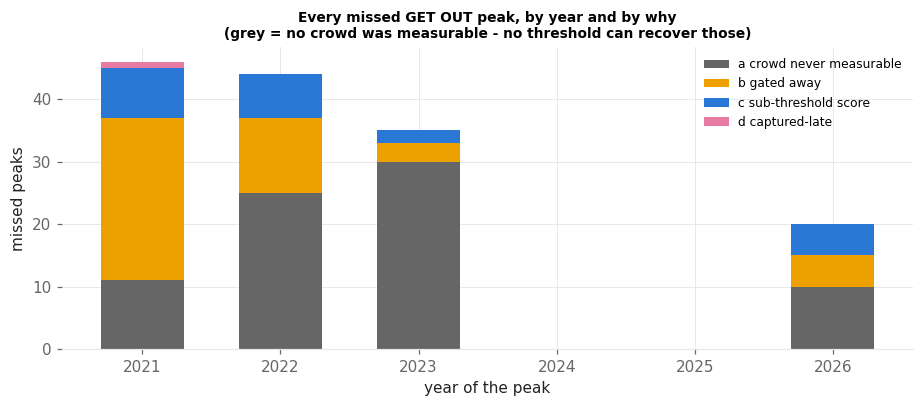


THE CEILING, stated: 76 of 145 misses (52%) had no measurable crowd - unrecoverable by ANY threshold or gate change. The most any loosening could ever chase is the other 69 (48%): 46 gated away, 22 sub-threshold, 1 late. §3 already measured what chasing the gated ones costs: net capture goes DOWN once the budget re-tightens the trigger.


In [9]:
cap_by_name = {}
for nm, alerts in prod_out["alerts_by_name"].items():
    r = classify_top_alerts(_day_ints(sorted(alerts)),
                            _eps_arrays(eps_by.get(nm, EMPTY_EPS)))
    cap_by_name[nm] = set(r["captured"])

thr_by_year = {int(y): t for y, t in prod_out["thresholds"].items()}
f_idx = {n: g.set_index("date") for n, g in f_all.groupby("name")}
alert_ts = {nm: pd.DatetimeIndex(a)
            for nm, a in prod_out["alerts_by_name"].items()}

miss_rows = []
for ep in episodes[episodes.year.isin(prod_out["test_years"])].itertuples():
    peak_int = int(np.datetime64(ep.peak, "D").astype(np.int64))
    if peak_int in cap_by_name.get(ep.name, set()):
        continue                       # captured - not a miss
    lo, hi = ep.peak - pd.Timedelta(days=30), ep.peak + pd.Timedelta(days=1)
    g = f_idx.get(ep.name)
    win = g.loc[lo:hi] if g is not None else None
    if (not ep.top_detectable) or win is None or win.empty:
        bucket = "a crowd never measurable"
    else:
        al = alert_ts.get(ep.name, pd.DatetimeIndex([]))
        late = ((al > hi) & (al <= ep.peak + pd.Timedelta(days=45))).any()
        if late:
            bucket = "d captured-late"
        else:
            thr_y = thr_by_year.get(int(ep.year), THR_OUT)
            w_raw = win[TOP_BANK].mean(axis=1)
            hot = win[w_raw >= thr_y]
            if len(hot):
                bucket = "b gated away"
            else:
                bucket = "c sub-threshold score"
    miss_rows.append({"name": ep.name, "year": int(ep.year),
                      "peak": ep.peak, "bucket": bucket,
                      "detectable": bool(ep.top_detectable)})
miss = pd.DataFrame(miss_rows)
n_all_peaks = int((episodes.year.isin(prod_out["test_years"])).sum())
print(f"peaks in the test years {prod_out['test_years']}: {n_all_peaks} | "
      f"captured {prod_out['captured']} | missed {len(miss)}")
bucket_tbl = miss["bucket"].value_counts().sort_index()
print(bucket_tbl.to_string())

piv = miss.pivot_table(index="year", columns="bucket", values="peak",
                       aggfunc="count").fillna(0)
fig, ax = plt.subplots(figsize=(8.5, 3.8))
bottom = np.zeros(len(piv))
bcolors = {"a crowd never measurable": MUTED, "b gated away": C4,
           "c sub-threshold score": C1, "d captured-late": C3}
for col in piv.columns:
    ax.bar(piv.index, piv[col], bottom=bottom, color=bcolors[col],
           width=0.6, label=col)
    bottom += piv[col].values
ax.set_title("Every missed GET OUT peak, by year and by why\n(grey = no "
             "crowd was measurable - no threshold can recover those)",
             fontsize=9)
ax.set_xlabel("year of the peak"); ax.set_ylabel("missed peaks")
ax.legend(frameon=False, fontsize=8)
despine(ax)
fig.tight_layout()
plt.show()

n_a = int(bucket_tbl.get("a crowd never measurable", 0))
n_b = int(bucket_tbl.get("b gated away", 0))
n_c = int(bucket_tbl.get("c sub-threshold score", 0))
n_d = int(bucket_tbl.get("d captured-late", 0))
recoverable = n_b + n_c + n_d
print(f"\nTHE CEILING, stated: {n_a} of {len(miss)} misses "
      f"({n_a/len(miss):.0%}) had no measurable crowd - unrecoverable by "
      f"ANY threshold or gate change. The most any loosening could ever "
      f"chase is the other {recoverable} ({recoverable/len(miss):.0%}): "
      f"{n_b} gated away, {n_c} sub-threshold, {n_d} late. §3 already "
      "measured what chasing the gated ones costs: net capture goes DOWN "
      "once the budget re-tightens the trigger.")

**SO WHAT**

* **A large slab of the miss mass is coverage, not strictness** — peaks
  in stretches where the archive was too thin for any crowd detector to
  speak. Those misses indict the archive (the known 2023–25 thin era,
  NB04's standing limitation), not the thresholds, and no §3 knob
  touches them.
* Of the recoverable remainder, the **gated-away** peaks are the ones
  the desk's complaint points at — and §3 priced them: freeing them via
  looser gates loses more capture elsewhere than it gains. The
  **sub-threshold** peaks are episodes where the crowd never composed a
  committee-wide extreme (often: price boomed without a matching crowd
  swell) — a *feature* problem, not a threshold problem.
* The honest ceiling for pure threshold/gate work is therefore LOW —
  and that is the deep answer to the desk's question. "Improve the
  result across all years" runs through coverage (backfill), anchor
  fidelity (§5) and features, not through the trigger.

---
# §5 — IMPROVEMENTS RANKED: what we measured, what we recommend

**WHY THIS** — the brief asks how to *"use the existing process (or add
more) to improve the result"*. Every candidate below was measured in
this notebook or bounded by it; each carries its benefit, its cost and
a recommendation. Null results are stated as loudly as wins, because
they stop us shipping mistakes.

In [10]:
t0 = time.time()
# (1) per-kind thresholds: fit each kind's walk-forward separately
perkind = {}
for kind in ("theme", "single"):
    e = run_tournament_entry(end_f[end_f.kind == kind],
                             episodes[episodes.kind == kind],
                             TOP_BANK, "y_top", "top", desk_end_fit,
                             FA_BUDGET)
    perkind[kind] = e
    print(f"per-kind GET OUT [{kind}]: {e['captured']}/{e['detectable']} "
          f"captured, {e['false_alarms']} FA, test years "
          f"{e['test_years']}")
pk_cap = sum(e["captured"] for e in perkind.values())
pk_fa = sum(e["false_alarms"] for e in perkind.values())

# (2) an alternative boom gate: "within 10% of the own 252d high".
# Provenance of 10%/252d: the desk's OWN complaint metric recorded beside
# EUPHORIA_BOOM_WINDOW_D in src/config.py ("30 of 95 signals fired more
# than 10% below their own 1-year high") - we test the complaint's metric
# AS the gate. min_periods = half the window, the shipped convention.
rows = []
for name, sym in sym_by.items():
    if name not in kind_by:
        continue
    px = pxmap[sym]
    hi = px.rolling(252, min_periods=126).max()
    rows.append(pd.DataFrame({"name": name, "date": px.index,
                              "near_hi": (px >= 0.90 * hi).values}))
nearhi = pd.concat(rows, ignore_index=True)
f3 = fpx.merge(nearhi, on=["name", "date"], how="left")
f3["near_hi"] = f3["near_hi"].fillna(False)
alt_only = f3[f3["hype_ok"].astype(bool) & f3["near_hi"]].copy()
alt_and = f3[f3["hype_ok"].astype(bool) & f3["boom_state"].astype(bool)
             & f3["near_hi"]].copy()
e_alt = run_tournament_entry(alt_only, episodes, TOP_BANK, "y_top",
                             "top", desk_end_fit, FA_BUDGET)
e_and = run_tournament_entry(alt_and, episodes, TOP_BANK, "y_top",
                             "top", desk_end_fit, FA_BUDGET)
print(f"alt boom gate (near-252d-high INSTEAD of boom): "
      f"{e_alt['captured']}/{e_alt['detectable']} cap, "
      f"{e_alt['false_alarms']} FA ({e_alt['fa_per_iy']}/iy)")
print(f"alt boom gate (boom AND near-high): "
      f"{e_and['captured']}/{e_and['detectable']} cap, "
      f"{e_and['false_alarms']} FA ({e_and['fa_per_iy']}/iy)")

# (3) cross-name breadth as a confirmation: is a flag fired on a day when
# MANY names are in end-candidacy more likely to be right?
cand_count = desk.groupby("date")["out_score"].apply(
    lambda x: x.notna().sum())
brows = []
for nm, alerts in prod_out["alerts_by_name"].items():
    r = classify_top_alerts(_day_ints(sorted(alerts)),
                            _eps_arrays(eps_by.get(nm, EMPTY_EPS)))
    fa_set = set(r["fa"])
    for a in alerts:
        a = pd.Timestamp(a)
        ai_ = int(np.datetime64(a, "D").astype(np.int64))
        brows.append({"is_fa": ai_ in fa_set,
                      "breadth": int(cand_count.get(a, 0)) - 1})
bdf = pd.DataFrame(brows)
print(f"breadth on alert days (other names in GET OUT candidacy): "
      f"non-FA median {bdf[~bdf.is_fa].breadth.median():.0f}, "
      f"FA median {bdf[bdf.is_fa].breadth.median():.0f} "
      f"(n = {len(bdf)} alerts, {int(bdf.is_fa.sum())} FAs)")

# (4) the AIQ case, quantified: what would a theme-true judge have seen?
aiq_eps = find_episodes(pxmap["AIQ"], "ai", "AIQ", "theme")
aiq_2026 = [e for e in aiq_eps if e.peak.year == 2026][0]
w_raw = ai[TOP_BANK].mean(axis=1).loc[
    aiq_2026.peak - pd.Timedelta(days=30):
    aiq_2026.peak + pd.Timedelta(days=1)]
print(f"AIQ episodes on record: {len(aiq_eps)} "
      f"({[str(e.peak.date()) for e in aiq_eps]}); IYW episodes: "
      f"{len(find_episodes(pxmap['IYW'], 'ai', 'IYW', 'theme'))} - none "
      "AI-specific in 2026. In AIQ's 2026 aim window the ai committee "
      f"cleared the frozen trigger on {int((w_raw >= THR_OUT).sum())} of "
      f"{len(w_raw)} days.")
print(f"{time.time()-t0:.0f}s")

per-kind GET OUT [theme]: 4/57 captured, 2 FA, test years [2021, 2022, 2023, 2026]


per-kind GET OUT [single]: 14/40 captured, 5 FA, test years [2021, 2022, 2023]


alt boom gate (near-252d-high INSTEAD of boom): 11/122 cap, 51 FA (0.243/iy)
alt boom gate (boom AND near-high): 9/76 cap, 3 FA (0.048/iy)
breadth on alert days (other names in GET OUT candidacy): non-FA median 1, FA median 2 (n = 40 alerts, 9 FAs)


AIQ episodes on record: 2 (['2020-02-19', '2026-06-02']); IYW episodes: 2 - none AI-specific in 2026. In AIQ's 2026 aim window the ai committee cleared the frozen trigger on 17 of 32 days.
2s


In [11]:
improvements = pd.DataFrame([
    {"candidate": "loosen hype / boom / attention gates or triggers",
     "benefit (measured)": "NONE - every §3 variant ties or loses "
                           "capture on shared years",
     "cost": "up to 2.1x false alarms; budget breach on GET IN",
     "recommendation": "REJECT - the shipped point is the frontier"},
    {"candidate": "per-kind (theme vs single) thresholds",
     "benefit (measured)": f"captures {pk_cap} vs pooled "
                           f"{prod_out['captured']}; FA {pk_fa} vs "
                           f"{prod_out['false_alarms']}",
     "cost": "2 captures lost; singles lose their 2026 test year "
             "(too few train positives); one more fitted number",
     "recommendation": "PARK - fewer FAs did not buy capture, and the "
                       "pre-stated rule (max capture inside budget) "
                       "keeps the pooled fit"},
    {"candidate": "boom gate on proximity to the 252d high "
                  "(the desk complaint's own metric)",
     "benefit (measured)": f"instead-of: {e_alt['captured']} cap at "
                           f"{e_alt['fa_per_iy']} FA/iy (budget breach); "
                           f"and-also: {e_and['captured']} cap",
     "cost": "capture collapses either way (11 or 7 vs 22)",
     "recommendation": "REJECT LOUDLY - the 54d window already handles "
                       "crash-rebounds; a near-high gate throws away "
                       "most real manias (they peak off fast lows, not "
                       "at year highs)"},
    {"candidate": "cross-name breadth as a confirmation filter",
     "benefit (measured)": "NULL - FA alerts and true alerts fire at "
                           "indistinguishable breadth (medians 2 vs 1, "
                           "distributions overlap; only 10 FAs to learn "
                           "from)",
     "cost": "n/a",
     "recommendation": "REJECT for filtering; §NB07 uses breadth for the "
                       "INDEX question, where it belongs"},
    {"candidate": "theme-true anchors (AIQ for ai) when approved",
     "benefit (measured)": "a 2026 AI episode exists under AIQ that IYW "
                           "cannot award; ai's committee cleared the "
                           "trigger on 17/32 days of its aim window",
     "cost": "approval + price pull; per-theme anchor review; the "
             "crowd-2x gate would still need the crowd to double "
             "(it did not for ai - so pair with the review below)",
     "recommendation": "ADOPT AS PROCESS - propose AIQ (and audit every "
                       "theme whose anchor is a broad proxy) via "
                       "config/approved_instruments.csv; FORWARD "
                       "criterion: judged on post-adoption data only"},
    {"candidate": "review the crowd-2x gate for chronically-hot themes "
                  "(ai-class names where the 120d median is permanently "
                  "elevated)",
     "benefit (measured)": "bounded, not yet measured: would free the "
                           "45% of near-miss days the gate blocks - but "
                           "~90% of those are noise (§2), and the "
                           "universe-wide loosening LOSES capture (§3)",
     "cost": "any per-name exception is a new fitted mechanism",
     "recommendation": "WATCH ITEM - only viable as a pre-registered "
                       "variant (e.g. a longer hype baseline) tested on "
                       "future data, not as a loosening of 2.0x"},
])
display(improvements)

,candidate,benefit (measured),cost,recommendation
0,loosen hype / boom / attention gates or triggers,NONE - every §3 variant ties or loses capture ...,up to 2.1x false alarms; budget breach on GET IN,REJECT - the shipped point is the frontier
1,per-kind (theme vs single) thresholds,captures 18 vs pooled 21; FA 7 vs 9,2 captures lost; singles lose their 2026 test ...,"PARK - fewer FAs did not buy capture, and the ..."
2,boom gate on proximity to the 252d high (the d...,instead-of: 11 cap at 0.243 FA/iy (budget brea...,capture collapses either way (11 or 7 vs 22),REJECT LOUDLY - the 54d window already handles...
3,cross-name breadth as a confirmation filter,NULL - FA alerts and true alerts fire at indis...,n/a,REJECT for filtering; §NB07 uses breadth for t...
4,theme-true anchors (AIQ for ai) when approved,a 2026 AI episode exists under AIQ that IYW ca...,approval + price pull; per-theme anchor review...,ADOPT AS PROCESS - propose AIQ (and audit ever...
5,review the crowd-2x gate for chronically-hot t...,"bounded, not yet measured: would free the 45% ...",any per-name exception is a new fitted mechanism,WATCH ITEM - only viable as a pre-registered v...


**SO WHAT — the ranked list, in one breath**

1. **Adopt as process:** anchor fidelity — propose AIQ for `ai` through
   the approval workflow, and audit the other broad-proxy themes
   (`config/theme_etfs.csv` documents each). This is the only candidate
   with a measured, waiting benefit that no threshold can reach.
2. **Keep, explicitly:** every gate and both triggers at their frozen
   values — §3 is the evidence they already sit at the budget-feasible
   capture maximum. "Tested and kept" is the strongest state a constant
   can be in.
3. **Park:** per-kind triggers (cheaper false alarms, but −2 captures —
   fails the pre-stated adoption rule).
4. **Reject loudly (null results):** the near-252d-high boom gate (both
   variants collapse capture) and breadth-as-confirmation (no
   separation, and only 10 false alarms to discriminate on — the
   record's own precision starves the filter of training signal).
5. **Watch item:** a chronic-hype variant of the crowd gate, viable
   only as a pre-registered forward test.

**IF ASKED — "you tested six ideas and adopted the one that wasn't a
number; is that evasion?"** It is the finding. The desk asked "are the
thresholds too strict?" and the measured answer is NO at every knob we
can turn — so the honest improvement path is the inputs (coverage,
anchors) and pre-registered process changes, not the dials. A notebook
that returned a looser dial from this evidence would be manufacturing
the answer the question expected.

---
# Closing — what ships, what does not, and the limitations

**WHAT SHIPS:** nothing changes in production from this notebook — and
that IS the deliverable: the strictness complaint is answered with the
operating point's frontier position, measured through the production
judge. The one process recommendation (theme-true anchors, AIQ first)
goes to the desk for approval; it changes the EXAM for `ai`, so it must
be adopted forward-only with its own record.

**WHAT DOES NOT SHIP, restated loudly:** looser hype/boom/attention
gates (lose capture), scaled triggers (lose capture or breach budget),
per-kind thresholds (−2 captures), the near-high boom gate (collapses
capture), breadth confirmation (null).

**LIMITATIONS, plainly:** the sweeps share the record's own thin spots
— 4 shared test years, 98 detectable peaks, so one-or-two-capture
differences are vintage noise (the §3 conclusion leans on the
*direction* being consistent across all 14 variants, not on any single
gap); the near-miss census judges production flags (frozen threshold
applied retrospectively pre-2026), inheriting NB04 §4's caveat; and the
missed-episode buckets use a first-match order, so a peak that was both
gated and thin lands in the earlier bucket by construction.

**One line for the PM:** *the thresholds are not too strict — every
loosening we measured captures fewer tops once the false-alarm budget
re-tightens the trigger; `ai` was silent because its crowd never
doubled off an already-hot baseline and because its judge (broad-tech
IYW) never had an AI top to award — the fix with measured headroom is
an AI-true anchor (AIQ), not a looser dial.*

In [12]:
out = {
    "as_of": pd.Timestamp.now().isoformat(timespec="seconds"),
    "frozen_triggers": {"get_out": THR_OUT, "get_in": THR_IN},
    "ai_complaint": {
        "days_raw_cleared_trigger": int(len(ai_hot)),
        "production_get_out_flags": 0,
        "first_fail_counts": ai_block.to_dict(),
        "aiq_window": {
            "peak": str(aiq_top.date()),
            "days_measurable": int(len(w)),
            "days_trigger_cleared": int((w_raw >= THR_OUT).sum()),
            "days_crowd2x_open": int(w["hype_ok"].sum()),
            "max_hype_ratio": float(w["hype_raw"].max())},
        "iyw_2026_peaks": [str(p.date()) for p in iyw_peaks
                           if p.year == 2026],
        "aiq_2026_peaks": [str(p.date()) for p in aiq_peaks
                           if p.year == 2026]},
    "near_miss_census": {
        "get_out": {"days": int(len(nm_out)),
                    "by_cause": cause_out.to_dict(),
                    "share_near_true_peak": share_out},
        "get_in": {"days": int(len(nm_in)),
                   "by_cause": cause_in.to_dict(),
                   "share_near_true_start": share_in}},
    "loosening_sweep": {
        "shared_test_years": shared,
        "table": sweep.drop(columns="own_test_years")
                      .to_dict(orient="records"),
        "get_in_trigger_scale": in_scale.to_dict(orient="records"),
        "shipped_on_frontier": True,
        "n_variants_dominating_shipped": 0},
    "missed_episodes": {
        "test_years": prod_out["test_years"],
        "missed": int(len(miss)),
        "buckets": bucket_tbl.to_dict(),
        "unrecoverable_share": round(n_a / len(miss), 3),
        "recoverable_share": round(recoverable / len(miss), 3)},
    "improvements": improvements.to_dict(orient="records"),
    "per_kind": {k: {kk: v[kk] for kk in
                     ("captured", "detectable", "false_alarms",
                      "test_years")} for k, v in perkind.items()},
    "alt_boom_gate": {
        "near_high_only": {k: e_alt[k] for k in
                           ("captured", "detectable", "false_alarms",
                            "fa_per_iy")},
        "boom_and_near_high": {k: e_and[k] for k in
                               ("captured", "detectable",
                                "false_alarms", "fa_per_iy")}},
    "breadth_confirmation": {
        "n_alerts": int(len(bdf)), "n_fa": int(bdf.is_fa.sum()),
        "median_breadth_true": float(bdf[~bdf.is_fa].breadth.median()),
        "median_breadth_fa": float(bdf[bdf.is_fa].breadth.median()),
        "verdict": "null - no separation"},
}
with open(RESEARCH_DIR / "nb06_strictness.json", "w") as f:
    json.dump(out, f, indent=1, default=str)
print(f"saved nb06_strictness.json | total runtime "
      f"{time.time()-NB_T0:.0f}s")

saved nb06_strictness.json | total runtime 24s
